# Shared-charge MS_DSA vs structural features

Only `MS_DSA_shared_charges`: light and heavy areas summed over the charge states measured in **both** channels.
It is NaN (never plotted) when a channel was not observed (`channel_absent`) or when the channels share no charge
state (`no_shared_charges`).

- **A. Zero areas included**: a shared channel may have zero area (`zero_area_shared`), giving MS_DSA = 0 or 1.
- **B. Zero areas excluded**: both shared areas are non-zero, so 0 < MS_DSA < 1.

Data: `data/ms_dsa/evaluation1/runs/run_*.parquet`; plotting functions: `dsa.ms_dsa.evaluation1.plots`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dsa.ms_dsa.evaluation1.ms_dsa_annotator import MSDSAAnnotator
from dsa.ms_dsa.evaluation1.plots import plot_dsa_vs_sasa_with_binding_annotation, binned_histogram, plot_runs

plt.rcParams.update({"font.size": 8, "figure.dpi": 100})

RUN_INDICES = range(5)
ms_dsa_by_run = {run_index: MSDSAAnnotator.load_run(run_index) for run_index in RUN_INDICES}

In [2]:
# plot settings
dsa_column = "MS_DSA_shared_charges"
bond_type = "salt_bridge"       # None for any contact
strict = False                  # inter-chain lysines that have no intra-chain PDB contact

# asa_nz of each contact class. Inter-chain peptides use the PDB biological assemblies (multimer), where a lysine
# has one value per chain copy: max over copies then max over the peptide's lysines (min: min then min).
# Intra AF and Not Contact use the AlphaFold monomer (one value per lysine): max / min over the peptide's lysines.
sasa_max = {"Inter": "asa_nz_multimer_max_max", "Intra AF": "asa_nz_max", "Not Contact": "asa_nz_max"}
sasa_min = {"Inter": "asa_nz_multimer_min_min", "Intra AF": "asa_nz_min", "Not Contact": "asa_nz_min"}
# section C: every group uses the multimer asa_nz (the groups are still defined by their contacts)
sasa_max_multimer = {"Inter": "asa_nz_multimer_max_max", "Intra AF": "asa_nz_multimer_max_max", "Not Contact": "asa_nz_multimer_max_max"}
sasa_min_multimer = {"Inter": "asa_nz_multimer_min_min", "Intra AF": "asa_nz_multimer_min_min", "Not Contact": "asa_nz_multimer_min_min"}

# histogram bin edges (last bin includes its right edge; np.inf makes an open-ended bin)
dsa_bins = [0.0, *np.linspace(0.1, 0.9, 4), *np.linspace(0.9, 1.0, 4)[1:]]
# 0-0.1, three equal bins over 0.1-0.9, three equal bins over 0.9-1
sasa_bins = [*np.arange(0.0, 61.0, 10.0), np.inf]     # width 10 up to 60, then >= 60 (multimer max goes up to ~81)

versions = {
    "A. zero areas included": ["channel_absent", "no_shared_charges"],
    "B. zero areas excluded": ["channel_absent", "no_shared_charges", "zero_area_shared"],
}
print("MS_DSA bins:", np.round(dsa_bins, 3))
print("asa_nz bins:", sasa_bins)

MS_DSA bins: [0.    0.1   0.367 0.633 0.9   0.933 0.967 1.   ]
asa_nz bins: [np.float64(0.0), np.float64(10.0), np.float64(20.0), np.float64(30.0), np.float64(40.0), np.float64(50.0), np.float64(60.0), inf]


In [3]:
# peptides per run in each version
for version, exclude in versions.items():
    counts = {}
    for run_index, ms_dsa in ms_dsa_by_run.items():
        keep = ms_dsa[dsa_column].notna()
        for flag in exclude:
            keep &= ~ms_dsa[flag]
        counts[run_index] = int(keep.sum())
    print(f"{version}: {counts}")

A. zero areas included: {0: 1580, 1: 1456, 2: 1361, 3: 1455, 4: 1840}
B. zero areas excluded: {0: 742, 1: 668, 2: 675, 3: 721, 4: 784}


## A. Zero areas included

MS_DSA histogram, then for asa_nz **max** (Inter: multimer max-max; Intra AF / Not Contact: AlphaFold max) and
asa_nz **min** (Inter: multimer min-min; Intra AF / Not Contact: AlphaFold min): the scatter plot and the histogram.

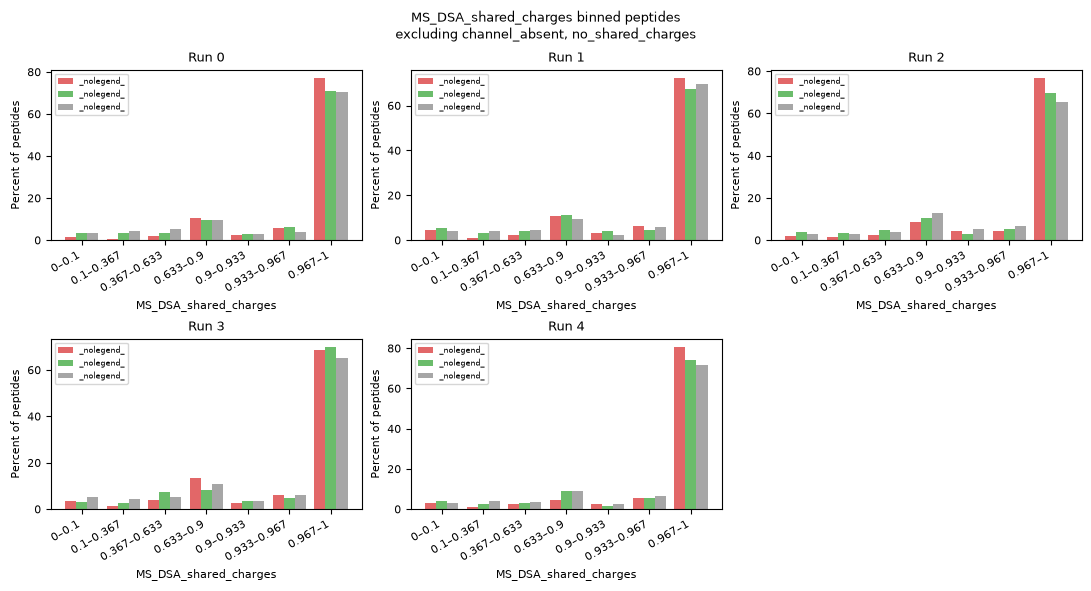

Inter PDB: 166 rows  (0.144 with MS_DSA_shared_charges < 0.9)
Intra PDB: 455 rows  (0.178 with MS_DSA_shared_charges < 0.9)
Intra AF: 507 rows  (0.199 with MS_DSA_shared_charges < 0.9)
Not contact: 939 rows  (0.224 with MS_DSA_shared_charges < 0.9)
Inter PDB: 139 rows  (0.185 with MS_DSA_shared_charges < 0.9)
Intra PDB: 388 rows  (0.212 with MS_DSA_shared_charges < 0.9)
Intra AF: 426 rows  (0.240 with MS_DSA_shared_charges < 0.9)
Not contact: 876 rows  (0.220 with MS_DSA_shared_charges < 0.9)
Inter PDB: 165 rows  (0.142 with MS_DSA_shared_charges < 0.9)
Intra PDB: 418 rows  (0.196 with MS_DSA_shared_charges < 0.9)
Intra AF: 411 rows  (0.223 with MS_DSA_shared_charges < 0.9)
Not contact: 771 rows  (0.225 with MS_DSA_shared_charges < 0.9)
Inter PDB: 155 rows  (0.224 with MS_DSA_shared_charges < 0.9)
Intra PDB: 424 rows  (0.206 with MS_DSA_shared_charges < 0.9)
Intra AF: 460 rows  (0.215 with MS_DSA_shared_charges < 0.9)
Not contact: 825 rows  (0.255 with MS_DSA_shared_charges < 0.9)
Inte

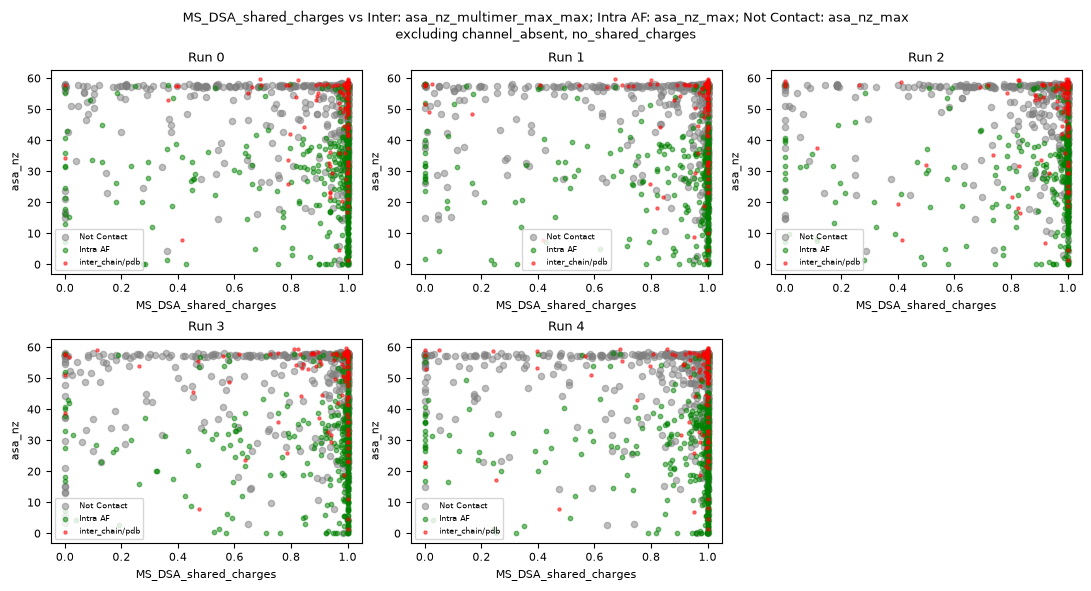

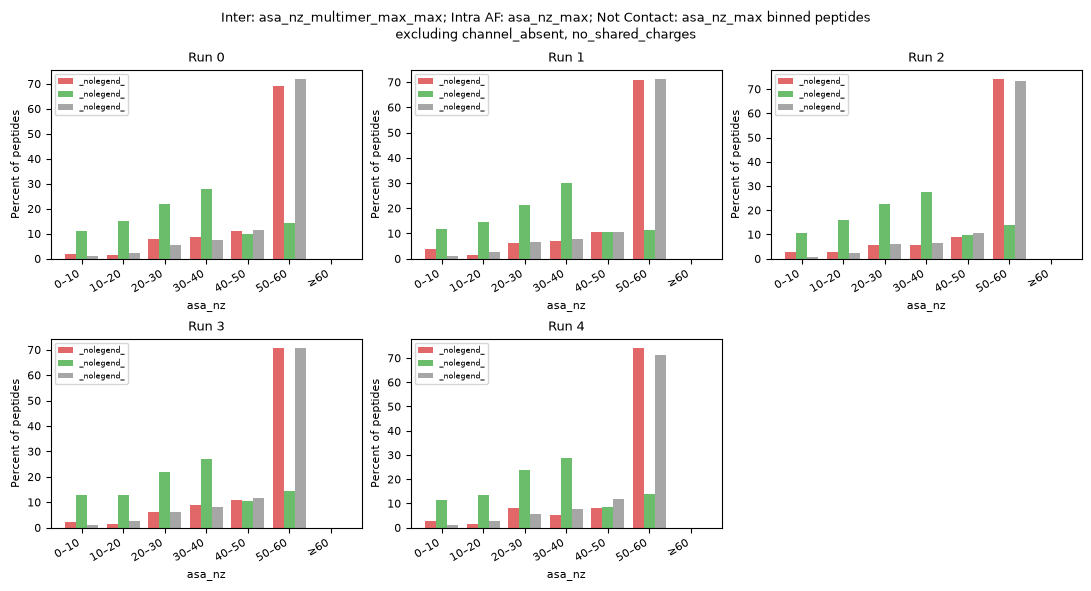

Inter PDB: 166 rows  (0.144 with MS_DSA_shared_charges < 0.9)
Intra PDB: 455 rows  (0.178 with MS_DSA_shared_charges < 0.9)
Intra AF: 507 rows  (0.199 with MS_DSA_shared_charges < 0.9)
Not contact: 939 rows  (0.224 with MS_DSA_shared_charges < 0.9)
Inter PDB: 139 rows  (0.185 with MS_DSA_shared_charges < 0.9)
Intra PDB: 388 rows  (0.212 with MS_DSA_shared_charges < 0.9)
Intra AF: 426 rows  (0.240 with MS_DSA_shared_charges < 0.9)
Not contact: 876 rows  (0.220 with MS_DSA_shared_charges < 0.9)
Inter PDB: 165 rows  (0.142 with MS_DSA_shared_charges < 0.9)
Intra PDB: 418 rows  (0.196 with MS_DSA_shared_charges < 0.9)
Intra AF: 411 rows  (0.223 with MS_DSA_shared_charges < 0.9)
Not contact: 771 rows  (0.225 with MS_DSA_shared_charges < 0.9)
Inter PDB: 155 rows  (0.224 with MS_DSA_shared_charges < 0.9)
Intra PDB: 424 rows  (0.206 with MS_DSA_shared_charges < 0.9)
Intra AF: 460 rows  (0.215 with MS_DSA_shared_charges < 0.9)
Not contact: 825 rows  (0.255 with MS_DSA_shared_charges < 0.9)
Inte

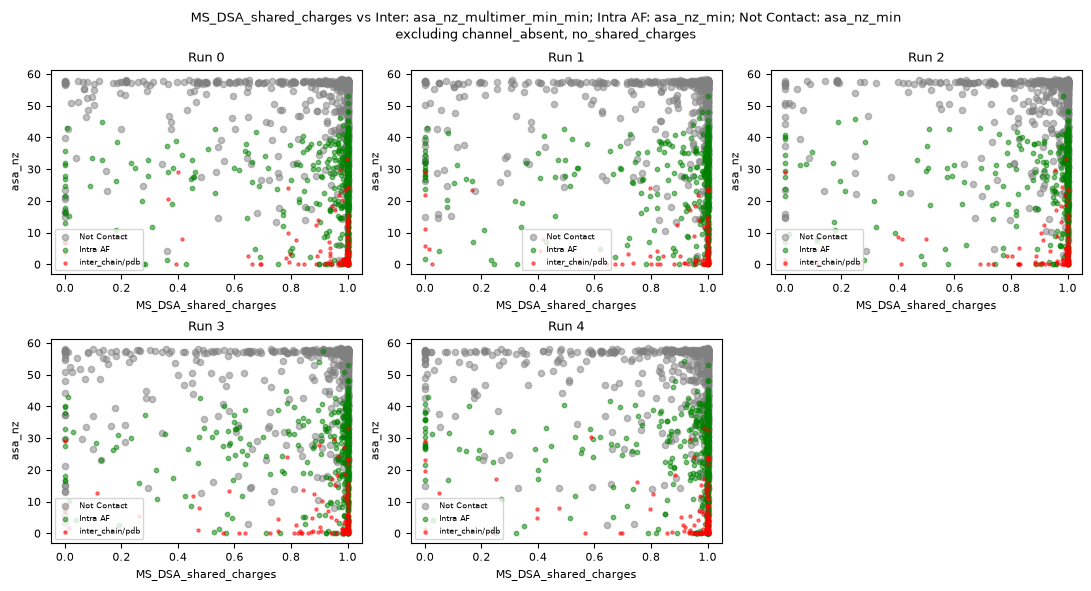

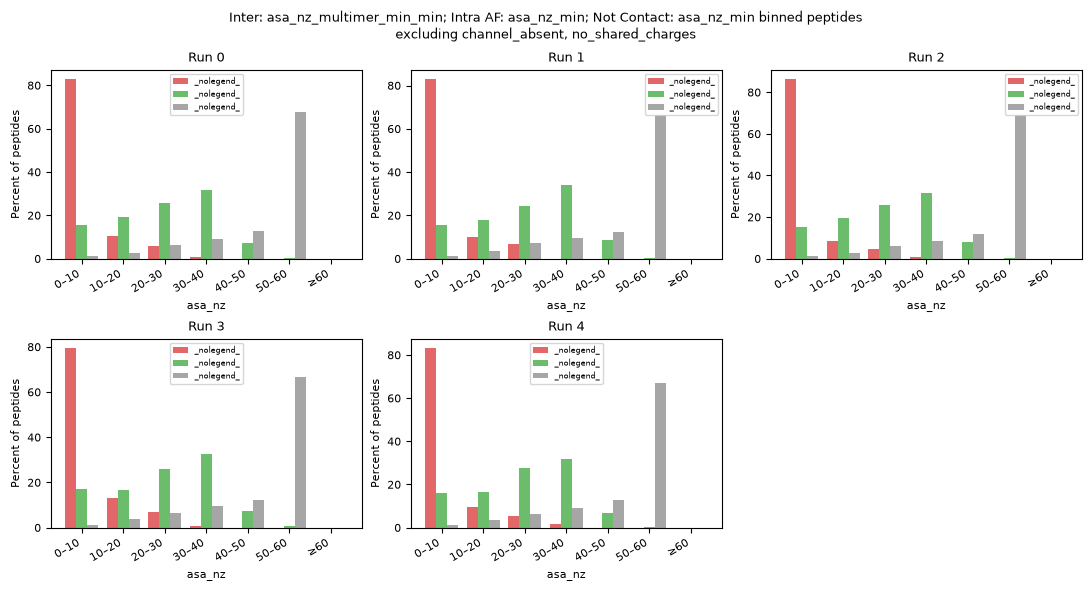

In [4]:
common = dict(bond_type=bond_type, strict=strict, exclude=versions["A. zero areas included"])
plot_runs(ms_dsa_by_run, binned_histogram, column=dsa_column, bins=dsa_bins, **common)
plt.show()
for sasa in (sasa_max, sasa_min):
    plot_runs(ms_dsa_by_run, plot_dsa_vs_sasa_with_binding_annotation, sasa_column=sasa, dsa_column=dsa_column, **common)
    plt.show()
    plot_runs(ms_dsa_by_run, binned_histogram, column=sasa, bins=sasa_bins, require=dsa_column, **common)
    plt.show()

## B. Zero areas excluded

MS_DSA histogram, then for asa_nz **max** (Inter: multimer max-max; Intra AF / Not Contact: AlphaFold max) and
asa_nz **min** (Inter: multimer min-min; Intra AF / Not Contact: AlphaFold min): the scatter plot and the histogram.

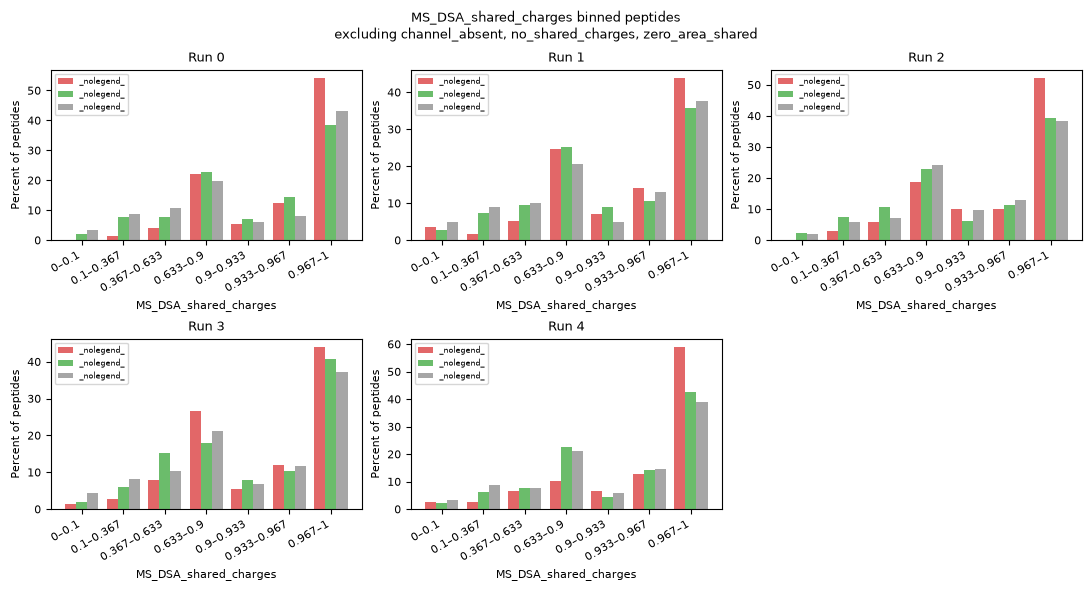

Inter PDB: 72 rows  (0.278 with MS_DSA_shared_charges < 0.9)
Intra PDB: 185 rows  (0.351 with MS_DSA_shared_charges < 0.9)
Intra AF: 203 rows  (0.404 with MS_DSA_shared_charges < 0.9)
Not contact: 432 rows  (0.426 with MS_DSA_shared_charges < 0.9)
Inter PDB: 57 rows  (0.351 with MS_DSA_shared_charges < 0.9)
Intra PDB: 170 rows  (0.388 with MS_DSA_shared_charges < 0.9)
Intra AF: 179 rows  (0.447 with MS_DSA_shared_charges < 0.9)
Not contact: 380 rows  (0.445 with MS_DSA_shared_charges < 0.9)
Inter PDB: 69 rows  (0.275 with MS_DSA_shared_charges < 0.9)
Intra PDB: 189 rows  (0.365 with MS_DSA_shared_charges < 0.9)
Intra AF: 178 rows  (0.433 with MS_DSA_shared_charges < 0.9)
Not contact: 387 rows  (0.390 with MS_DSA_shared_charges < 0.9)
Inter PDB: 75 rows  (0.387 with MS_DSA_shared_charges < 0.9)
Intra PDB: 203 rows  (0.379 with MS_DSA_shared_charges < 0.9)
Intra AF: 202 rows  (0.411 with MS_DSA_shared_charges < 0.9)
Not contact: 406 rows  (0.441 with MS_DSA_shared_charges < 0.9)
Inter PD

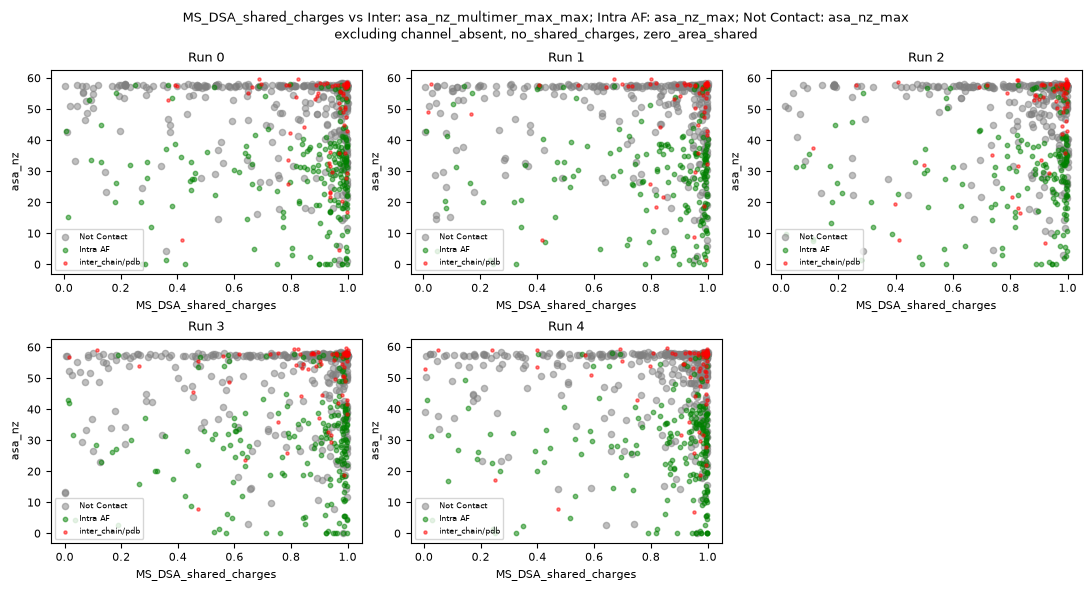

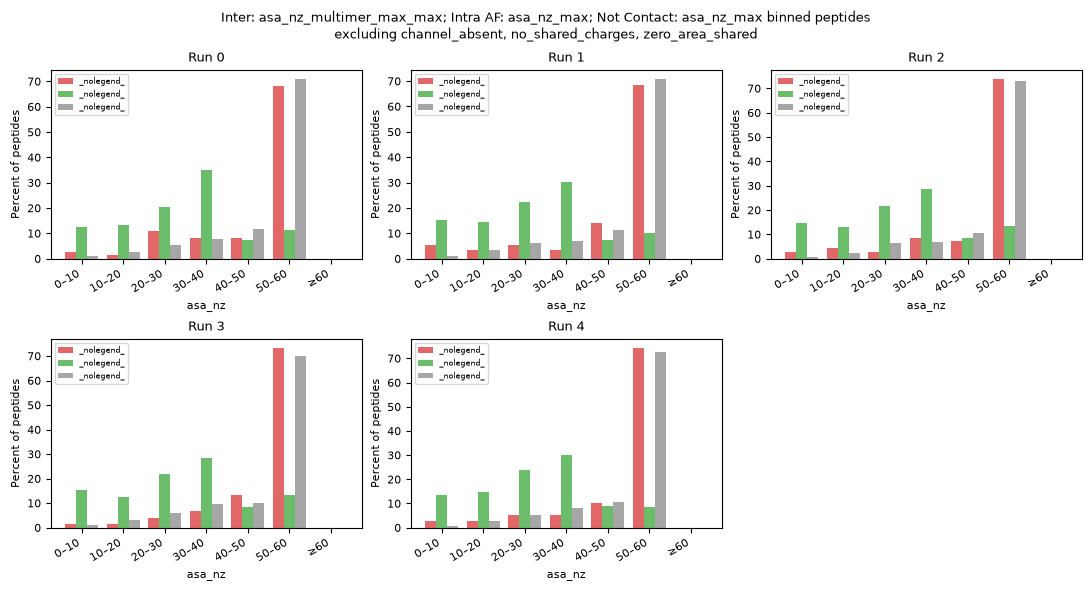

Inter PDB: 72 rows  (0.278 with MS_DSA_shared_charges < 0.9)
Intra PDB: 185 rows  (0.351 with MS_DSA_shared_charges < 0.9)
Intra AF: 203 rows  (0.404 with MS_DSA_shared_charges < 0.9)
Not contact: 432 rows  (0.426 with MS_DSA_shared_charges < 0.9)
Inter PDB: 57 rows  (0.351 with MS_DSA_shared_charges < 0.9)
Intra PDB: 170 rows  (0.388 with MS_DSA_shared_charges < 0.9)
Intra AF: 179 rows  (0.447 with MS_DSA_shared_charges < 0.9)
Not contact: 380 rows  (0.445 with MS_DSA_shared_charges < 0.9)
Inter PDB: 69 rows  (0.275 with MS_DSA_shared_charges < 0.9)
Intra PDB: 189 rows  (0.365 with MS_DSA_shared_charges < 0.9)
Intra AF: 178 rows  (0.433 with MS_DSA_shared_charges < 0.9)
Not contact: 387 rows  (0.390 with MS_DSA_shared_charges < 0.9)
Inter PDB: 75 rows  (0.387 with MS_DSA_shared_charges < 0.9)
Intra PDB: 203 rows  (0.379 with MS_DSA_shared_charges < 0.9)
Intra AF: 202 rows  (0.411 with MS_DSA_shared_charges < 0.9)
Not contact: 406 rows  (0.441 with MS_DSA_shared_charges < 0.9)
Inter PD

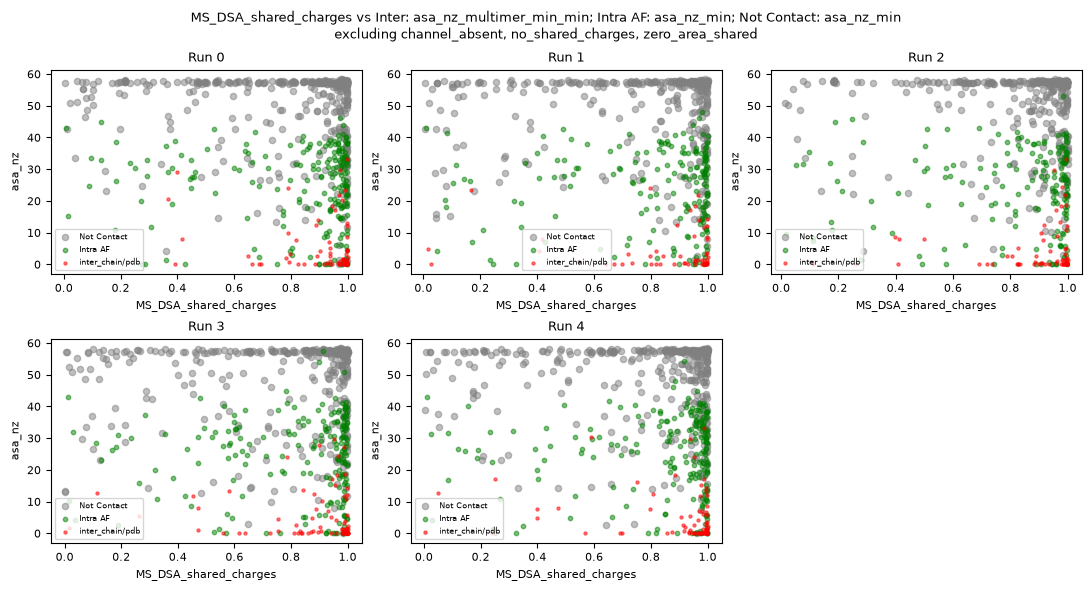

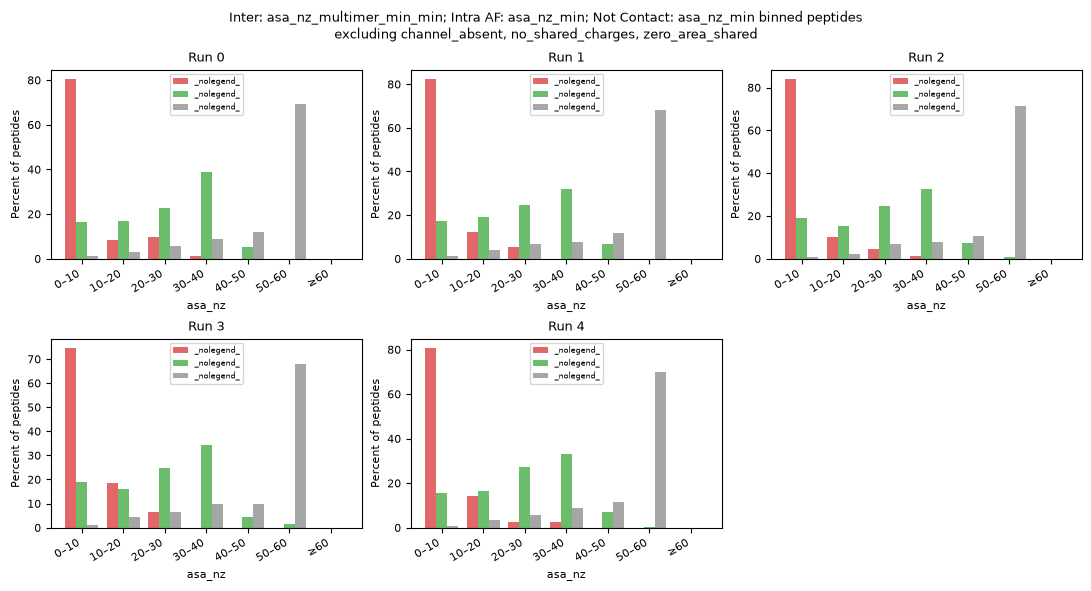

In [5]:
common = dict(bond_type=bond_type, strict=strict, exclude=versions["B. zero areas excluded"])
plot_runs(ms_dsa_by_run, binned_histogram, column=dsa_column, bins=dsa_bins, **common)
plt.show()
for sasa in (sasa_max, sasa_min):
    plot_runs(ms_dsa_by_run, plot_dsa_vs_sasa_with_binding_annotation, sasa_column=sasa, dsa_column=dsa_column, **common)
    plt.show()
    plot_runs(ms_dsa_by_run, binned_histogram, column=sasa, bins=sasa_bins, require=dsa_column, **common)
    plt.show()

## C. All groups use asa_nz from the multimer structures

Inter, Intra AF and Not Contact peptides all use the PDB biological assembly asa_nz (**max**: max over chain copies
then over lysines; **min**: min then min). The groups are still defined by their contacts (Intra AF by AlphaFold
intra-chain contacts), so only peptides whose lysines are all in a PDB structure have a value.
Shown for both versions (A: zero areas included, B: zero areas excluded).

Inter PDB: 166 rows  (0.144 with MS_DSA_shared_charges < 0.9)
Intra PDB: 455 rows  (0.178 with MS_DSA_shared_charges < 0.9)
Intra AF: 507 rows  (0.199 with MS_DSA_shared_charges < 0.9)
Not contact: 939 rows  (0.224 with MS_DSA_shared_charges < 0.9)
Inter PDB: 139 rows  (0.185 with MS_DSA_shared_charges < 0.9)
Intra PDB: 388 rows  (0.212 with MS_DSA_shared_charges < 0.9)
Intra AF: 426 rows  (0.240 with MS_DSA_shared_charges < 0.9)
Not contact: 876 rows  (0.220 with MS_DSA_shared_charges < 0.9)
Inter PDB: 165 rows  (0.142 with MS_DSA_shared_charges < 0.9)
Intra PDB: 418 rows  (0.196 with MS_DSA_shared_charges < 0.9)
Intra AF: 411 rows  (0.223 with MS_DSA_shared_charges < 0.9)
Not contact: 771 rows  (0.225 with MS_DSA_shared_charges < 0.9)
Inter PDB: 155 rows  (0.224 with MS_DSA_shared_charges < 0.9)
Intra PDB: 424 rows  (0.206 with MS_DSA_shared_charges < 0.9)
Intra AF: 460 rows  (0.215 with MS_DSA_shared_charges < 0.9)
Not contact: 825 rows  (0.255 with MS_DSA_shared_charges < 0.9)
Inte

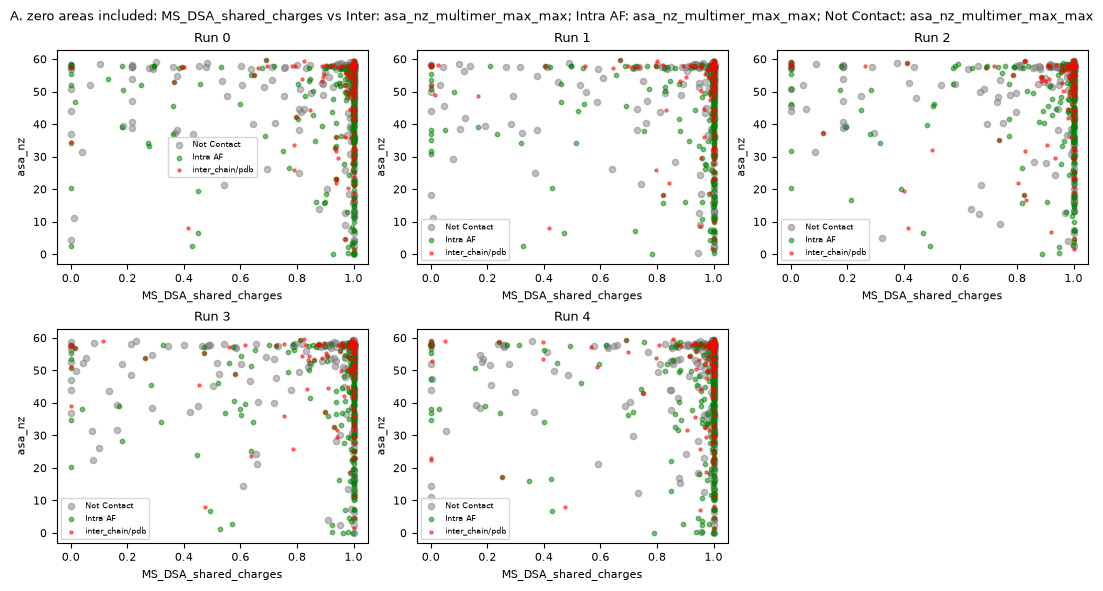

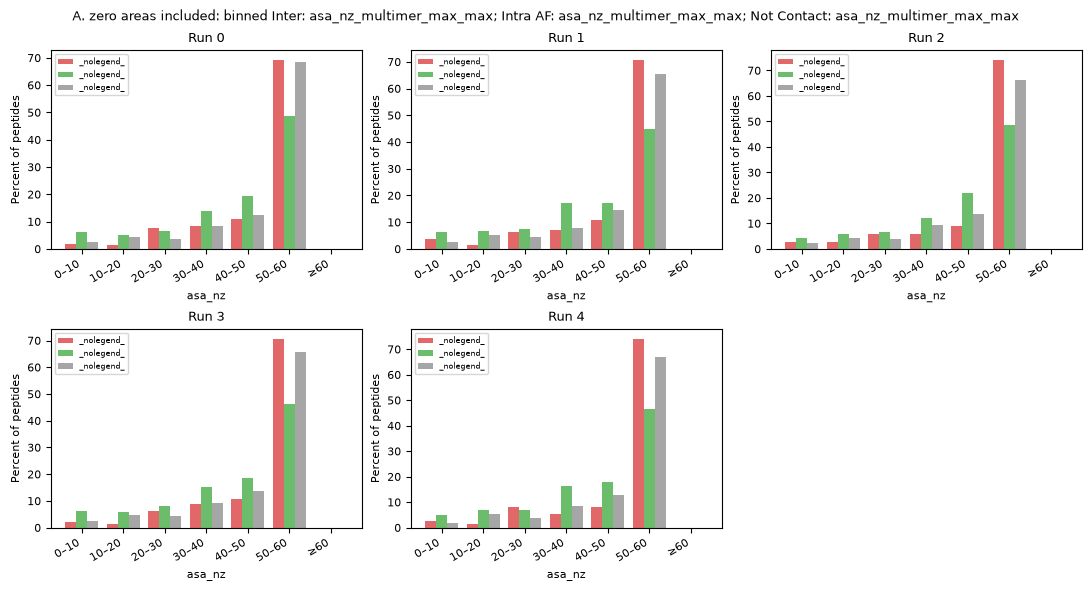

Inter PDB: 166 rows  (0.144 with MS_DSA_shared_charges < 0.9)
Intra PDB: 455 rows  (0.178 with MS_DSA_shared_charges < 0.9)
Intra AF: 507 rows  (0.199 with MS_DSA_shared_charges < 0.9)
Not contact: 939 rows  (0.224 with MS_DSA_shared_charges < 0.9)
Inter PDB: 139 rows  (0.185 with MS_DSA_shared_charges < 0.9)
Intra PDB: 388 rows  (0.212 with MS_DSA_shared_charges < 0.9)
Intra AF: 426 rows  (0.240 with MS_DSA_shared_charges < 0.9)
Not contact: 876 rows  (0.220 with MS_DSA_shared_charges < 0.9)
Inter PDB: 165 rows  (0.142 with MS_DSA_shared_charges < 0.9)
Intra PDB: 418 rows  (0.196 with MS_DSA_shared_charges < 0.9)
Intra AF: 411 rows  (0.223 with MS_DSA_shared_charges < 0.9)
Not contact: 771 rows  (0.225 with MS_DSA_shared_charges < 0.9)
Inter PDB: 155 rows  (0.224 with MS_DSA_shared_charges < 0.9)
Intra PDB: 424 rows  (0.206 with MS_DSA_shared_charges < 0.9)
Intra AF: 460 rows  (0.215 with MS_DSA_shared_charges < 0.9)
Not contact: 825 rows  (0.255 with MS_DSA_shared_charges < 0.9)
Inte

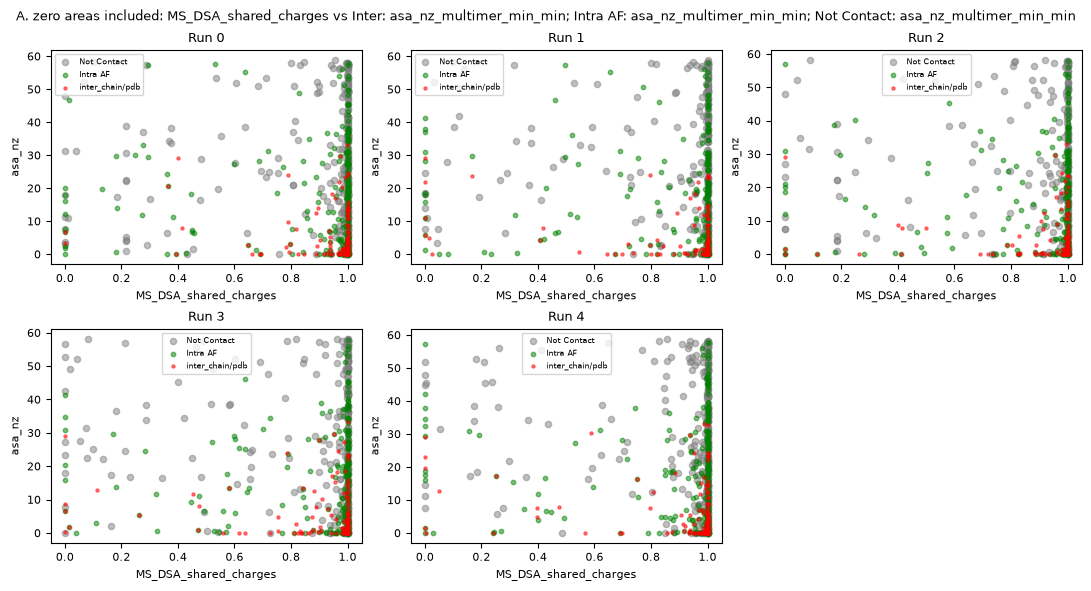

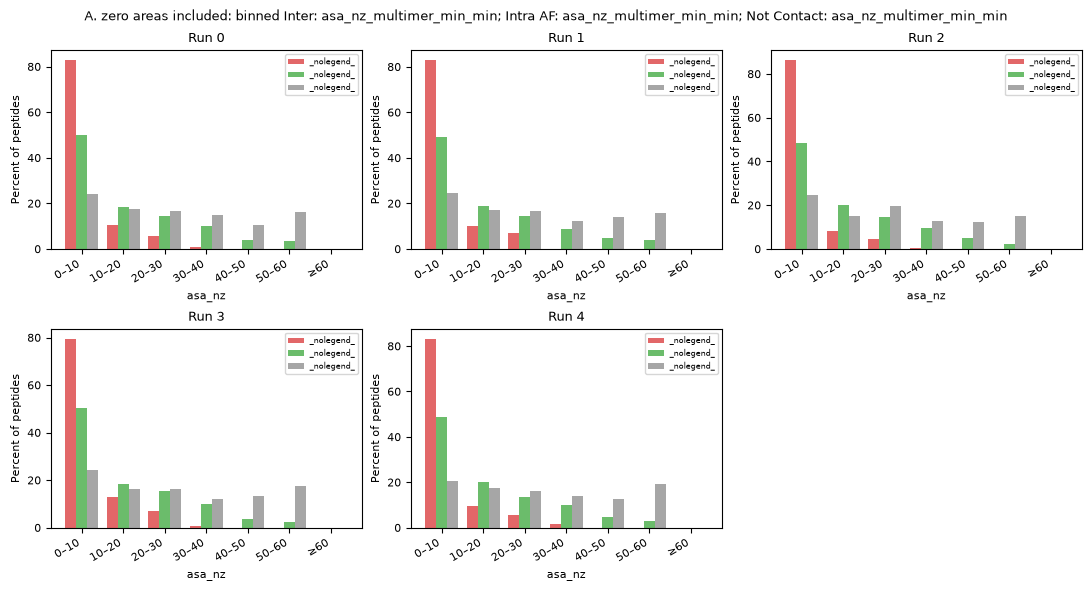

Inter PDB: 72 rows  (0.278 with MS_DSA_shared_charges < 0.9)
Intra PDB: 185 rows  (0.351 with MS_DSA_shared_charges < 0.9)
Intra AF: 203 rows  (0.404 with MS_DSA_shared_charges < 0.9)
Not contact: 432 rows  (0.426 with MS_DSA_shared_charges < 0.9)
Inter PDB: 57 rows  (0.351 with MS_DSA_shared_charges < 0.9)
Intra PDB: 170 rows  (0.388 with MS_DSA_shared_charges < 0.9)
Intra AF: 179 rows  (0.447 with MS_DSA_shared_charges < 0.9)
Not contact: 380 rows  (0.445 with MS_DSA_shared_charges < 0.9)
Inter PDB: 69 rows  (0.275 with MS_DSA_shared_charges < 0.9)
Intra PDB: 189 rows  (0.365 with MS_DSA_shared_charges < 0.9)
Intra AF: 178 rows  (0.433 with MS_DSA_shared_charges < 0.9)
Not contact: 387 rows  (0.390 with MS_DSA_shared_charges < 0.9)
Inter PDB: 75 rows  (0.387 with MS_DSA_shared_charges < 0.9)
Intra PDB: 203 rows  (0.379 with MS_DSA_shared_charges < 0.9)
Intra AF: 202 rows  (0.411 with MS_DSA_shared_charges < 0.9)
Not contact: 406 rows  (0.441 with MS_DSA_shared_charges < 0.9)
Inter PD

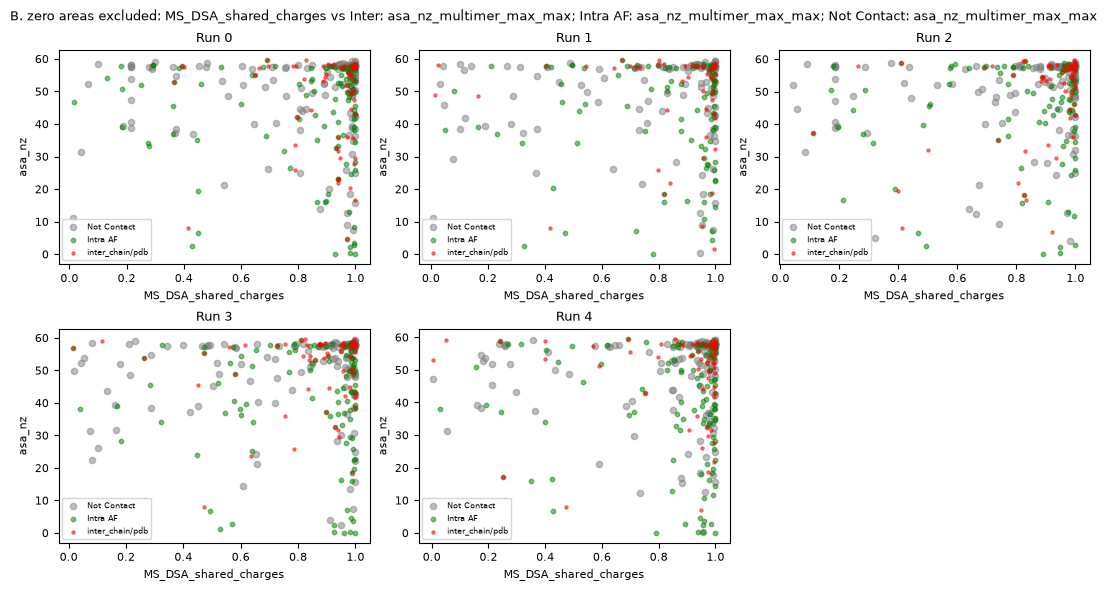

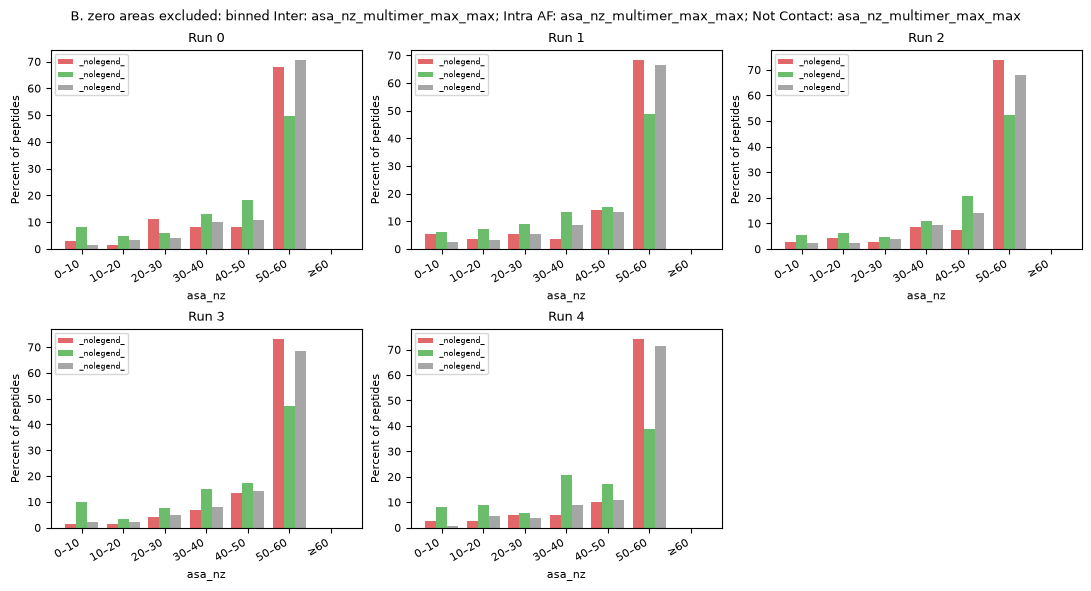

Inter PDB: 72 rows  (0.278 with MS_DSA_shared_charges < 0.9)
Intra PDB: 185 rows  (0.351 with MS_DSA_shared_charges < 0.9)
Intra AF: 203 rows  (0.404 with MS_DSA_shared_charges < 0.9)
Not contact: 432 rows  (0.426 with MS_DSA_shared_charges < 0.9)
Inter PDB: 57 rows  (0.351 with MS_DSA_shared_charges < 0.9)
Intra PDB: 170 rows  (0.388 with MS_DSA_shared_charges < 0.9)
Intra AF: 179 rows  (0.447 with MS_DSA_shared_charges < 0.9)
Not contact: 380 rows  (0.445 with MS_DSA_shared_charges < 0.9)
Inter PDB: 69 rows  (0.275 with MS_DSA_shared_charges < 0.9)
Intra PDB: 189 rows  (0.365 with MS_DSA_shared_charges < 0.9)
Intra AF: 178 rows  (0.433 with MS_DSA_shared_charges < 0.9)
Not contact: 387 rows  (0.390 with MS_DSA_shared_charges < 0.9)
Inter PDB: 75 rows  (0.387 with MS_DSA_shared_charges < 0.9)
Intra PDB: 203 rows  (0.379 with MS_DSA_shared_charges < 0.9)
Intra AF: 202 rows  (0.411 with MS_DSA_shared_charges < 0.9)
Not contact: 406 rows  (0.441 with MS_DSA_shared_charges < 0.9)
Inter PD

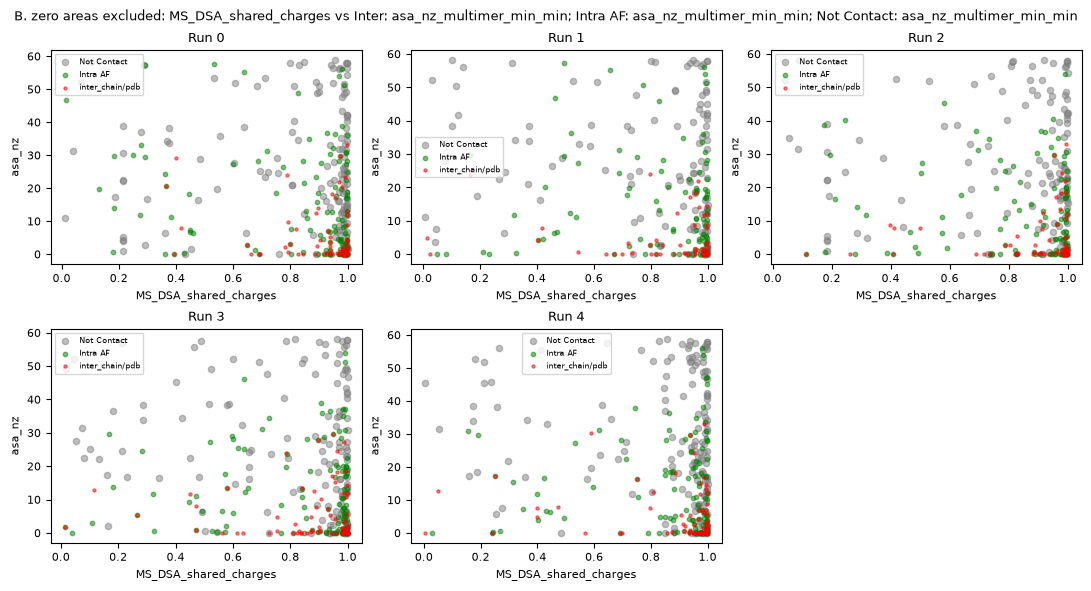

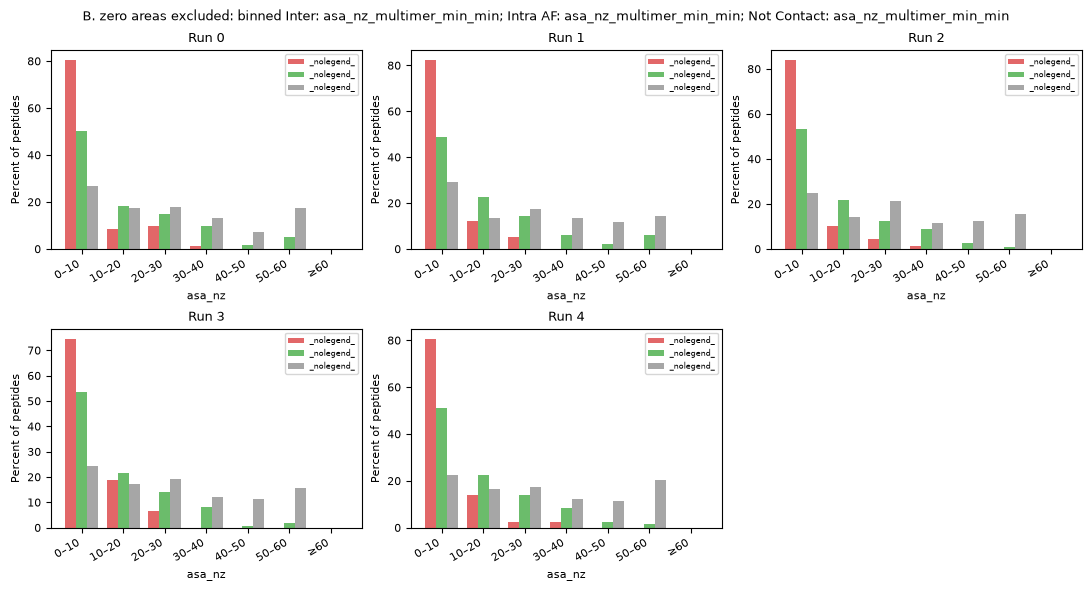

In [6]:
for version, exclude in versions.items():
    common = dict(bond_type=bond_type, strict=strict, exclude=exclude)
    for sasa in (sasa_max_multimer, sasa_min_multimer):
        plot_runs(ms_dsa_by_run, plot_dsa_vs_sasa_with_binding_annotation, sasa_column=sasa, dsa_column=dsa_column,
                  suptitle=f"{version}: {dsa_column} vs " + "; ".join(f"{g}: {c}" for g, c in sasa.items()), **common)
        plt.show()
        plot_runs(ms_dsa_by_run, binned_histogram, column=sasa, bins=sasa_bins, require=dsa_column,
                  suptitle=f"{version}: binned " + "; ".join(f"{g}: {c}" for g, c in sasa.items()), **common)
        plt.show()